In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent  # move up from notebooks/ to project root

DATA = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

ROOT

DATA = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

inc = pd.read_csv(DATA / "fact_incident.csv")
wo  = pd.read_csv(DATA / "fact_work_order.csv")
loc = pd.read_csv(DATA / "dim_location.csv")
feat = pd.read_csv(DATA / "incident_features.csv")

for c in ["reported_at", "closed_at", "arrived_at", "completed_at"]:
    if c in feat.columns:
        feat[c] = pd.to_datetime(feat[c], errors="coerce")

feat.head()


,incident_id,incident_type,reported_at,channel,severity,description,location_id,asset_id,status,duplicate_of_incident_id,expected_sla_hours,closed_at,arrived_at,completed_at,first_response_hours,repair_days,sla_breached
0,INC_000000001,WATER_LEAK,2025-08-03 13:25:58,WHATSAPP,3,Pipe burst suspected,LOC_001967,AST_003262,CLOSED,NaN,36,2025-08-06 04:14:06.687567868,2025-08-04 04:06:55.528122213,2025-08-05 02:27:56.270881093,14.682647,1.543036,False
1,INC_000000002,WATER_LEAK,2025-05-04 18:22:40,FIELD_CREW,4,Pipe burst suspected,LOC_000545,AST_003354,CLOSED,INC_000000001,24,2025-05-09 02:50:36.118228551,2025-05-05 06:04:39.722078540,2025-05-06 23:32:36.150124618,11.699923,2.215233,False
2,INC_000000003,POTHOLE,2025-04-21 19:04:45,APP,3,Large pothole near intersection,LOC_001576,AST_001568,CLOSED,NaN,72,2025-04-25 09:48:16.832127494,2025-04-22 13:24:54.581277425,2025-04-23 08:59:05.127511097,18.335995,1.579400,False
3,INC_000000004,WATER_LEAK,2025-06-05 00:26:05,WHATSAPP,2,Continuous leak near sidewalk,LOC_000797,AST_000022,CLOSED,NaN,48,2025-06-08 00:22:57.793126479,2025-06-06 19:04:09.316172348,2025-06-09 11:53:32.940676762,42.634532,4.477407,False
4,INC_000000005,WATER_LEAK,2025-11-01 09:55:21,CALL_CENTER,3,Water flowing on street,LOC_000114,AST_000286,DISPATCHED,NaN,36,NaT,2025-11-02 10:37:56.329306686,2025-11-05 19:57:17.270523383,24.709814,4.418012,False


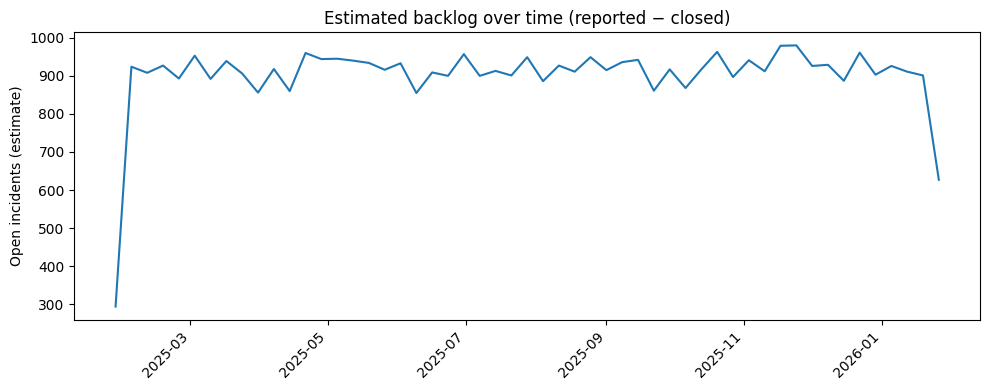

In [3]:
# Backlog over time (reported vs closed)

feat["week"] = feat["reported_at"].dt.to_period("W").dt.start_time

backlog = (
    feat.groupby("week", as_index=False)
        .agg(
            reported=("incident_id", "count"),
            closed=("closed_at", lambda s: s.notna().sum())
        )
)

backlog["open_estimate"] = backlog["reported"] - backlog["closed"]

plt.figure(figsize=(10,4))
plt.plot(backlog["week"], backlog["open_estimate"])
plt.xticks(rotation=45, ha="right")
plt.title("Estimated backlog over time (reported − closed)")
plt.ylabel("Open incidents (estimate)")
plt.tight_layout()
plt.savefig(FIG / "backlog_trend.png", dpi=200)
plt.show()


<Figure size 600x400 with 0 Axes>

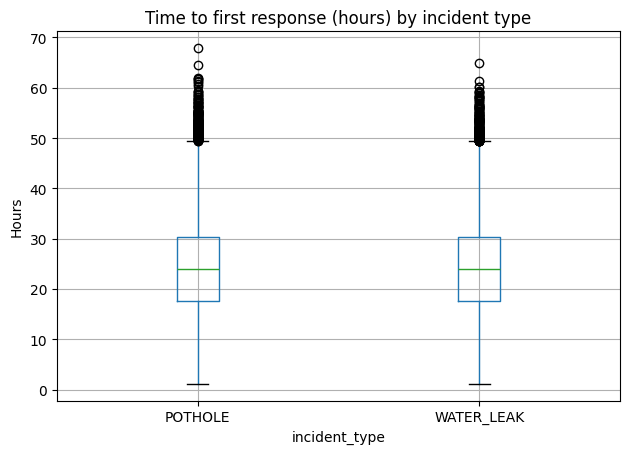

,count,mean,std,min,25%,50%,75%,max
incident_type,,,,,,,,
POTHOLE,96372.0,24.114418,8.778251,1.134474,17.594890,24.016972,30.356384,67.886494
WATER_LEAK,79419.0,24.093247,8.767136,1.143583,17.589135,23.994697,30.302648,64.865452


In [4]:
# Time to first response by incident type

rt = feat.dropna(subset=["first_response_hours"])

plt.figure(figsize=(6,4))
rt.boxplot(column="first_response_hours", by="incident_type")
plt.suptitle("")
plt.title("Time to first response (hours) by incident type")
plt.ylabel("Hours")
plt.tight_layout()
plt.savefig(FIG / "first_response_by_type.png", dpi=200)
plt.show()

rt.groupby("incident_type")["first_response_hours"].describe()


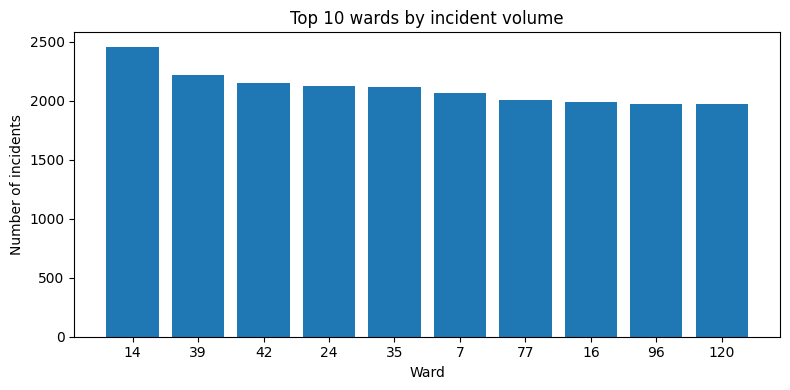

,ward_number,incidents
13,14,2458
38,39,2215
41,42,2155
23,24,2122
34,35,2116
6,7,2067
76,77,2009
15,16,1987
95,96,1975
119,120,1973


In [5]:
# Top 10 wards by incident volume

top_wards = (
    feat.merge(loc[["location_id", "ward_number"]], on="location_id", how="left")
        .groupby("ward_number", as_index=False)
        .agg(incidents=("incident_id", "count"))
        .sort_values("incidents", ascending=False)
        .head(10)
)

plt.figure(figsize=(8,4))
plt.bar(top_wards["ward_number"].astype(str), top_wards["incidents"])
plt.title("Top 10 wards by incident volume")
plt.xlabel("Ward")
plt.ylabel("Number of incidents")
plt.tight_layout()
plt.savefig(FIG / "top_wards.png", dpi=200)
plt.show()

top_wards


In [6]:
# Write Phase 1 summary report

summary = {
    "total_incidents": int(feat["incident_id"].nunique()),
    "median_response_hrs": float(feat["first_response_hours"].median()),
    "median_repair_days": float(feat["repair_days"].median()),
    "sla_breach_rate": float(feat["sla_breached"].mean())
}

report_text = f"""
# Phase 1 – KPI Summary (Johannesburg Municipal Infrastructure)

## Key Metrics
- Total incidents analysed: {summary['total_incidents']:,}
- Median time-to-first-response (hours): {summary['median_response_hrs']:.2f}
- Median time-to-repair (days): {summary['median_repair_days']:.2f}
- SLA breach rate: {summary['sla_breach_rate']:.1%}

## Generated Figures
- reports/figures/backlog_trend.png
- reports/figures/first_response_by_type.png
- reports/figures/top_wards.png
"""

(ROOT / "reports" / "report.md").write_text(report_text, encoding="utf-8")
print("reports/report.md updated ✅")


reports/report.md updated ✅
